# Experiment 02: GPR B-scan Object Detection

**Goal**: Localize subsurface anomalies in GPR radargrams, not just classify them.

This moves from "this image contains a cavity" (classification) to "there's a cavity at (x, y) with size (w, h)" (detection). This is the stepping stone toward fossil-like anomaly detection.

See `docs/experiment_02_detection.md` for the full experiment spec.

**Models**:
- A: YOLOv8n (nano) -- fast, modern single-stage detector
- B: YOLOv8s (small) -- slightly larger, potentially better on small objects

**Two framings**:
- 2-class: cavity (0) vs utility (1)
- Binary: anomaly (0) -- both collapsed

**Key question from Grad-CAM analysis**: The classification model attends well to cavity regions (51% attention in bbox) but poorly to utility bbox regions (18%). Detection models should do better since they're explicitly trained to localize.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd
import yaml

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.config import PROCESSED_DATA_DIR, RESULTS_DIR, FIGURES_DIR

DETECTION_DIR = PROCESSED_DATA_DIR / "detection"
MODELS_DIR = RESULTS_DIR / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Verify data exists
for mode in ["2class", "binary"]:
    yaml_path = DETECTION_DIR / mode / "dataset.yaml"
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    print(f"\n{mode} dataset config:")
    for k, v in cfg.items():
        print(f"  {k}: {v}")
    
    # Count files
    for split in ["train", "val", "test"]:
        img_dir = DETECTION_DIR / mode / split / "images"
        lbl_dir = DETECTION_DIR / mode / split / "labels"
        n_imgs = len(list(img_dir.glob("*.jpg")))
        n_lbls = len(list(lbl_dir.glob("*.txt")))
        n_nonempty = sum(1 for f in lbl_dir.glob("*.txt") if f.stat().st_size > 0)
        print(f"  {split}: {n_imgs} images, {n_lbls} labels ({n_nonempty} with objects)")


2class dataset config:
  names: ['cavity', 'utility']
  nc: 2
  path: /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/2class
  test: test/images
  train: train/images
  val: val/images
  train: 1413 images, 1413 labels (931 with objects)
  val: 311 images, 311 labels (191 with objects)
  test: 365 images, 365 labels (217 with objects)

binary dataset config:
  names: ['anomaly']
  nc: 1
  path: /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/binary
  test: test/images
  train: train/images
  val: val/images
  train: 1413 images, 1413 labels (931 with objects)
  val: 311 images, 311 labels (191 with objects)
  test: 365 images, 365 labels (217 with objects)


## 1. Visualize Detection Data

Quick sanity check: display some images with their ground truth bounding boxes to make sure the data conversion was correct.

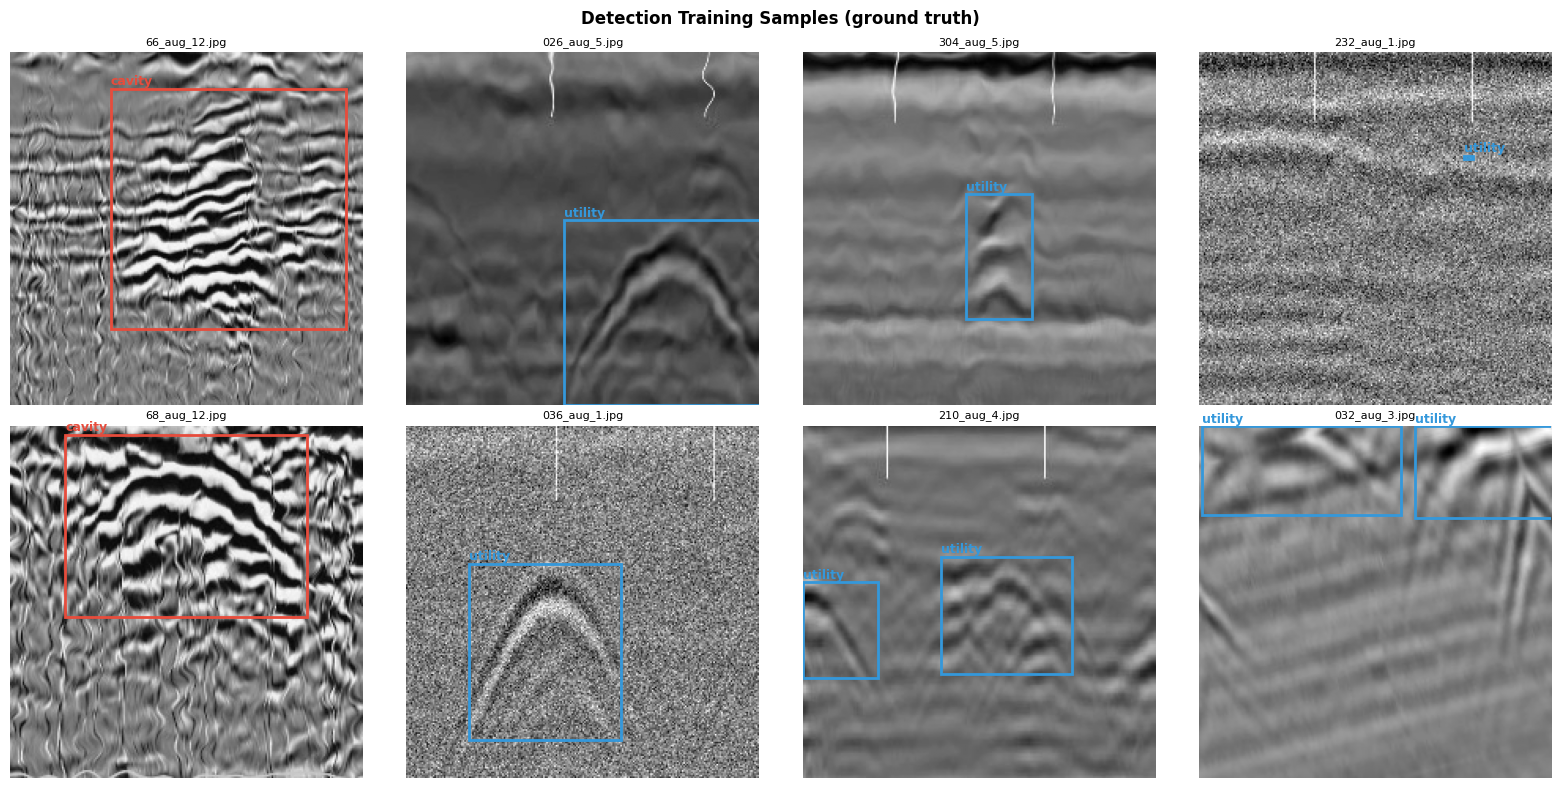

In [2]:
CLASS_NAMES_2CLASS = ["cavity", "utility"]
CLASS_COLORS = {"cavity": "#e74c3c", "utility": "#3498db", "anomaly": "#e74c3c"}


def load_yolo_labels(lbl_path):
    """Load YOLO label file. Returns list of (class_id, cx, cy, w, h) normalized."""
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return []
    boxes = []
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                boxes.append(tuple(float(x) for x in parts[:5]))
    return boxes


def show_detection_samples(data_dir, class_names, n_samples=8, seed=42):
    """Show sample images with ground truth boxes."""
    rng = np.random.RandomState(seed)
    img_dir = data_dir / "train" / "images"
    lbl_dir = data_dir / "train" / "labels"

    # Find images with annotations
    annotated = []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        boxes = load_yolo_labels(lbl_path)
        if boxes:
            annotated.append((img_path, boxes))

    chosen = rng.choice(len(annotated), size=min(n_samples, len(annotated)), replace=False)

    fig, axes = plt.subplots(2, n_samples // 2, figsize=(4 * (n_samples // 2), 8))
    axes = axes.flatten()

    for ax_idx, data_idx in enumerate(chosen):
        img_path, boxes = annotated[data_idx]
        img = np.array(Image.open(img_path).convert("L"))
        h_img, w_img = img.shape

        axes[ax_idx].imshow(img, cmap="gray")
        for cls_id, cx, cy, w, h in boxes:
            px_cx, px_cy = cx * w_img, cy * h_img
            px_w, px_h = w * w_img, h * h_img
            x_min = px_cx - px_w / 2
            y_min = px_cy - px_h / 2
            cls_name = class_names[int(cls_id)]
            color = CLASS_COLORS.get(cls_name, "lime")
            rect = patches.Rectangle((x_min, y_min), px_w, px_h,
                                      linewidth=2, edgecolor=color, facecolor="none")
            axes[ax_idx].add_patch(rect)
            axes[ax_idx].text(x_min, y_min - 3, cls_name, color=color, fontsize=9, fontweight="bold")
        axes[ax_idx].set_title(img_path.name, fontsize=8)
        axes[ax_idx].axis("off")

    plt.suptitle(f"Detection Training Samples (ground truth)", fontweight="bold")
    plt.tight_layout()
    plt.show()


show_detection_samples(DETECTION_DIR / "2class", CLASS_NAMES_2CLASS, n_samples=8)

## 2. Train YOLOv8 (2-Class Detection)

Starting with YOLOv8n (nano) on the 2-class framing: cavity vs utility. Using COCO-pretrained weights as initialization. Images are 224x224, which is small for YOLO (default is 640), but we'll start with the native size to avoid upscaling artifacts.

Training config:
- 100 epochs with patience=20 for early stopping
- Image size: 640 (YOLO's default, it will resize internally)
- Batch size: 16
- Default augmentation (mosaic, mixup, etc.)

In [3]:
from ultralytics import YOLO

# Train YOLOv8n on 2-class detection
dataset_yaml = str(DETECTION_DIR / "2class" / "dataset.yaml")
results_dir = str(RESULTS_DIR / "detection" / "yolov8n_2class")

model = YOLO("yolov8n.pt")  # pretrained nano model

results = model.train(
    data=dataset_yaml,
    epochs=100,
    patience=20,
    imgsz=640,
    batch=16,
    project=str(RESULTS_DIR / "detection"),
    name="yolov8n_2class",
    exist_ok=True,
    device=0,
    workers=4,
    seed=42,
    verbose=True,
)

print("\nTraining complete.")

New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.23 🚀 Python-3.11.15 torch-2.12.0.dev20260316+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32087MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/2class/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_2class, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=

Overriding model.yaml nc=80 with nc=2



                   from  n    params  module                                       arguments                     


...

                cavity         77         84      0.885      0.702      0.784      0.402


               utility        114        141      0.763      0.618      0.733      0.395


Speed: 0.0ms preprocess, 0.3ms inference, 0.0ms loss, 0.5ms postprocess per image


Results saved to /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/results/detection/yolov8n_2class



Training complete.


## 3. Evaluate on Test Set

In [4]:
# Load best model and evaluate on test set
best_model_path = RESULTS_DIR / "detection" / "yolov8n_2class" / "weights" / "best.pt"
model = YOLO(str(best_model_path))

# Run validation on test split
test_results = model.val(
    data=dataset_yaml,
    split="test",
    imgsz=640,
    batch=16,
    verbose=True,
)

print(f"\n{'='*60}")
print("YOLOv8n 2-Class Detection -- TEST SET RESULTS")
print(f"{'='*60}")
print(f"mAP@0.5:     {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"\nPer-class AP@0.5:")
for i, cls_name in enumerate(["cavity", "utility"]):
    if i < len(test_results.box.ap50):
        print(f"  {cls_name}: {test_results.box.ap50[i]:.4f}")

Ultralytics 8.4.23 🚀 Python-3.11.15 torch-2.12.0.dev20260316+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32087MiB)


Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1297.2±505.9 MB/s, size: 9.9 KB)


val: Scanning /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/2class/test/labels... 365 images, 148 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 365/365 9.4Kit/s 0.0s

val: New cache created: /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/2class/test/labels.cache


...

                cavity         91        104      0.633      0.547      0.538      0.271


               utility        126        192      0.666      0.572      0.625      0.321


Speed: 0.3ms preprocess, 0.5ms inference, 0.0ms loss, 0.3ms postprocess per image


Results saved to /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/notebooks/runs/detect/val



YOLOv8n 2-Class Detection -- TEST SET RESULTS
mAP@0.5:     0.5814
mAP@0.5:0.95: 0.2960

Per-class AP@0.5:
  cavity: 0.5377
  utility: 0.6251


## 4. Visualize Detections

Show predicted boxes vs ground truth on test images. Green = ground truth, red = prediction.

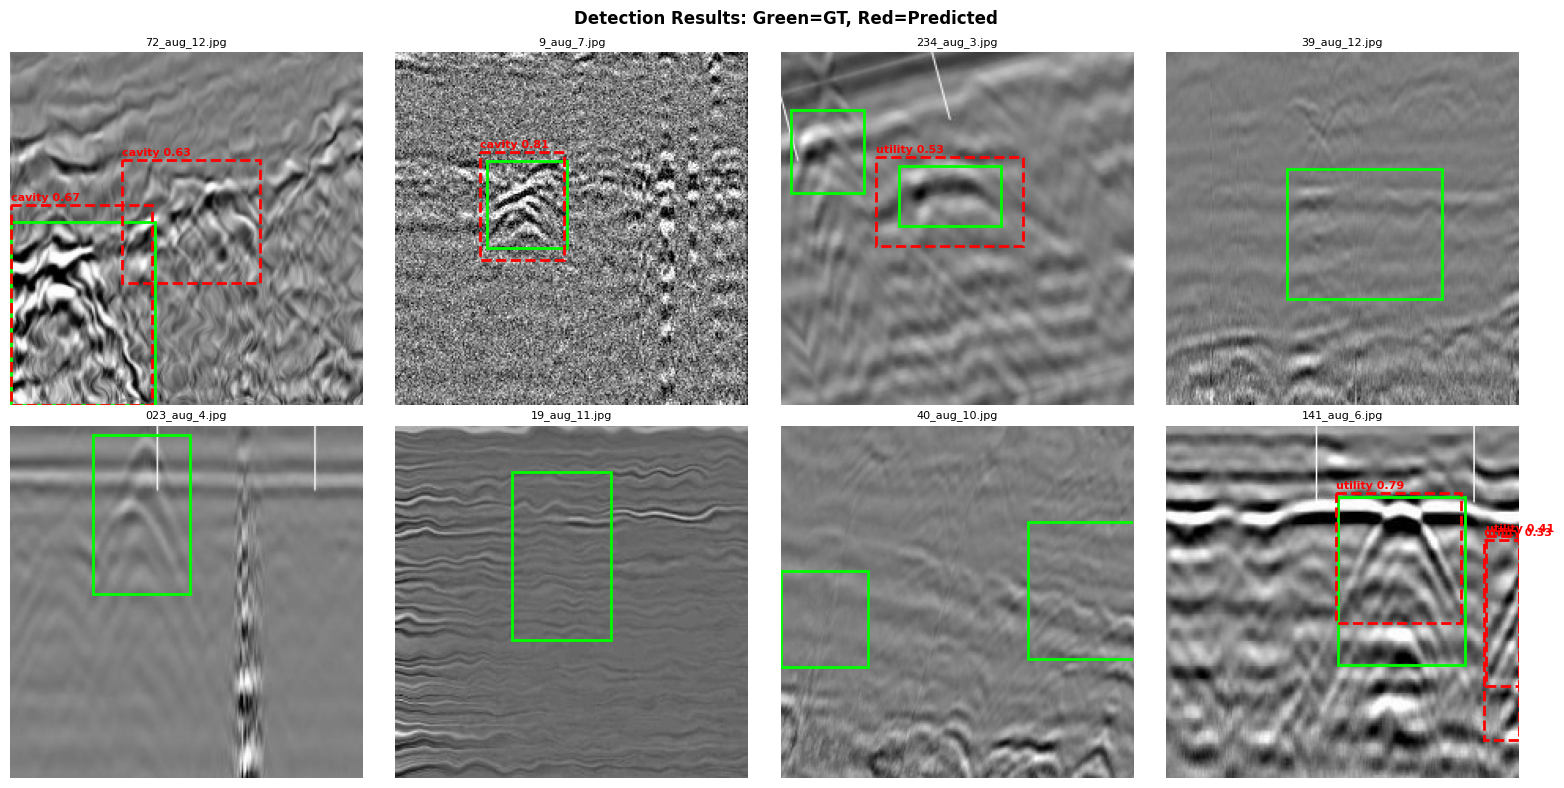

In [5]:
def show_predictions(model, data_dir, class_names, n_samples=8, seed=42, conf_thresh=0.25):
    """Show predicted vs ground truth boxes."""
    rng = np.random.RandomState(seed)
    img_dir = data_dir / "test" / "images"
    lbl_dir = data_dir / "test" / "labels"

    # Get annotated images
    annotated = []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        boxes = load_yolo_labels(lbl_path)
        if boxes:
            annotated.append((img_path, boxes))

    chosen = rng.choice(len(annotated), size=min(n_samples, len(annotated)), replace=False)

    fig, axes = plt.subplots(2, n_samples // 2, figsize=(4 * (n_samples // 2), 8))
    axes = axes.flatten()

    for ax_idx, data_idx in enumerate(chosen):
        img_path, gt_boxes = annotated[data_idx]
        img = np.array(Image.open(img_path).convert("RGB"))
        h_img, w_img = img.shape[:2]

        # Run prediction
        preds = model.predict(str(img_path), imgsz=640, conf=conf_thresh, verbose=False)
        pred_boxes = preds[0].boxes

        axes[ax_idx].imshow(img[:, :, 0], cmap="gray")

        # Ground truth (green)
        for cls_id, cx, cy, w, h in gt_boxes:
            px_w, px_h = w * w_img, h * h_img
            x_min = cx * w_img - px_w / 2
            y_min = cy * h_img - px_h / 2
            rect = patches.Rectangle((x_min, y_min), px_w, px_h,
                                      linewidth=2, edgecolor="lime", facecolor="none")
            axes[ax_idx].add_patch(rect)

        # Predictions (red)
        if pred_boxes is not None and len(pred_boxes) > 0:
            for box in pred_boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                conf = box.conf[0].cpu().item()
                cls_id = int(box.cls[0].cpu().item())
                x1, y1, x2, y2 = xyxy
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                          linewidth=2, edgecolor="red", facecolor="none", linestyle="--")
                axes[ax_idx].add_patch(rect)
                cls_name = class_names[cls_id] if cls_id < len(class_names) else f"cls{cls_id}"
                axes[ax_idx].text(x1, y1 - 3, f"{cls_name} {conf:.2f}",
                                   color="red", fontsize=8, fontweight="bold")

        axes[ax_idx].set_title(img_path.name, fontsize=8)
        axes[ax_idx].axis("off")

    fig.suptitle("Detection Results: Green=GT, Red=Predicted", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "detection_predictions_2class.png", bbox_inches="tight", dpi=150)
    plt.show()


show_predictions(model, DETECTION_DIR / "2class", CLASS_NAMES_2CLASS, n_samples=8)

## 5. False Positive Analysis on Intact Images

Critical check: how often does the detector hallucinate objects on intact B-scans where there's nothing to find?

In [6]:
# Check false positive rate on intact (background) images
test_img_dir = DETECTION_DIR / "2class" / "test" / "images"
test_lbl_dir = DETECTION_DIR / "2class" / "test" / "labels"

# Find intact images (empty label files)
intact_images = []
for img_path in sorted(test_img_dir.glob("*.jpg")):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists() and lbl_path.stat().st_size == 0:
        intact_images.append(img_path)

print(f"Intact (background) test images: {len(intact_images)}")

# Run predictions on intact images
fp_count = 0
fp_details = []

for img_path in intact_images:
    preds = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False)
    n_detections = len(preds[0].boxes) if preds[0].boxes is not None else 0
    if n_detections > 0:
        fp_count += 1
        confs = [b.conf[0].item() for b in preds[0].boxes]
        fp_details.append({"file": img_path.name, "n_detections": n_detections, "max_conf": max(confs)})

fp_rate = fp_count / len(intact_images) if intact_images else 0
print(f"\nFalse positive rate on intact images: {fp_count}/{len(intact_images)} = {fp_rate:.1%}")
if fp_details:
    print(f"\nFalse positive details:")
    for d in fp_details[:10]:
        print(f"  {d['file']}: {d['n_detections']} detections, max_conf={d['max_conf']:.3f}")

Intact (background) test images: 148



False positive rate on intact images: 1/148 = 0.7%

False positive details:
  40_aug_1.jpg: 1 detections, max_conf=0.440


## 6. Train Binary Anomaly Detector

Same setup but with the binary framing: cavity and utility both become "anomaly" class 0. This might generalize better to fossil-like targets since we don't care about the anomaly type.

In [7]:
# Train YOLOv8n on binary detection
binary_yaml = str(DETECTION_DIR / "binary" / "dataset.yaml")

model_binary = YOLO("yolov8n.pt")

results_binary = model_binary.train(
    data=binary_yaml,
    epochs=100,
    patience=20,
    imgsz=640,
    batch=16,
    project=str(RESULTS_DIR / "detection"),
    name="yolov8n_binary",
    exist_ok=True,
    device=0,
    workers=4,
    seed=42,
    verbose=True,
)

print("\nBinary training complete.")

New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.23 🚀 Python-3.11.15 torch-2.12.0.dev20260316+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32087MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/binary/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_binary, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 21.1it/s 0.5s

                   all        311        225       0.79      0.636      0.728      0.375


Speed: 0.1ms preprocess, 0.3ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/results/detection/yolov8n_binary



Binary training complete.


In [8]:
# Evaluate binary model on test set
best_binary = RESULTS_DIR / "detection" / "yolov8n_binary" / "weights" / "best.pt"
model_binary = YOLO(str(best_binary))

test_binary = model_binary.val(
    data=binary_yaml,
    split="test",
    imgsz=640,
    batch=16,
    verbose=True,
)

print(f"\n{'='*60}")
print("YOLOv8n Binary Anomaly Detection -- TEST SET RESULTS")
print(f"{'='*60}")
print(f"mAP@0.5:     {test_binary.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_binary.box.map:.4f}")
print(f"AP@0.5 (anomaly): {test_binary.box.ap50[0]:.4f}" if len(test_binary.box.ap50) > 0 else "")

Ultralytics 8.4.23 🚀 Python-3.11.15 torch-2.12.0.dev20260316+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32087MiB)


Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1731.6±1323.2 MB/s, size: 16.1 KB)


val: Scanning /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/binary/test/labels... 365 images, 148 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 365/365 8.6Kit/s 0.0s

val: New cache created: /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/data/processed/detection/binary/test/labels.cache


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 32.0it/s 0.7s

                   all        365        296      0.647      0.598        0.6      0.312


Speed: 0.4ms preprocess, 0.4ms inference, 0.0ms loss, 0.2ms postprocess per image


Results saved to /home/michael-ramirez/GitHub/personal/paleo-gpr-ml/notebooks/runs/detect/val2



YOLOv8n Binary Anomaly Detection -- TEST SET RESULTS
mAP@0.5:     0.5999
mAP@0.5:0.95: 0.3117
AP@0.5 (anomaly): 0.5999


## 7. Summary Comparison

Compare both framings side by side.

In [9]:
# Summary table
summary = pd.DataFrame({
    "Model": ["YOLOv8n (2-class)", "YOLOv8n (binary)"],
    "mAP@0.5": [test_results.box.map50, test_binary.box.map50],
    "mAP@0.5:0.95": [test_results.box.map, test_binary.box.map],
})

print(summary.to_string(index=False))

# Save
summary.to_csv(RESULTS_DIR / "tables" / "detection_results.csv", index=False)
print(f"\nSaved to results/tables/detection_results.csv")

            Model  mAP@0.5  mAP@0.5:0.95
YOLOv8n (2-class) 0.581399      0.295976
 YOLOv8n (binary) 0.599911      0.311651

Saved to results/tables/detection_results.csv


## 8. Conclusions and Next Steps

**What to look for in the results:**

- mAP@0.5 > 0.50 is the minimum to show anomalies are localizable
- mAP@0.5 > 0.70 is good
- Binary vs 2-class comparison tells us whether collapsing to a single anomaly class helps
- False positive rate on intact images tells us how clean the detector is

**Next steps based on results:**
- If detection works well: move to synthetic fossil-like data with gprMax
- If detection is weak: investigate annotation quality, try larger model (YOLOv8s), or consider segmentation framing
- Either way: write up notes in `docs/notes/05_detection_experiment_notes.md` and update `docs/research_log.md`